<a href="https://colab.research.google.com/github/lillian181/INST750LG/blob/main/pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Analysis and Added English Translation Evaluation

## What this project does

This notebook evaluates a text classification task using an OpenAI chat model as a zero-shot classifier.

The original workflow is:

1. Load `dev.csv` from the Colab file system.
2. Treat the file as tab-separated data with no header.
3. Rename the two columns to:
   - `label`: the gold/true class
   - `text`: the input text to classify
4. Collect all unique labels from the dataset.
5. Ask the OpenAI model to classify each text into exactly one of those labels.
6. Evaluate predictions using:
   - `classification_report`
   - `confusion_matrix`

## Stronger rigor addition beyond a confusion matrix and classification report

A useful rigor improvement is to add **stratified sampling + bootstrap confidence intervals + error analysis**.

Why this helps:

- The original notebook evaluates only the first 100 rows, which may not represent all classes fairly.
- A stratified sample keeps the label distribution more balanced across classes.
- Bootstrap confidence intervals show how stable the accuracy/F1 results are instead of reporting only one score.
- Error analysis shows which examples changed after translation and where the translated English version helped or hurt.

The added code below evaluates both:

1. The original text
2. The English-translated text

Then it compares their performance.

In [12]:
# ============================================================
# SETUP: installs, imports, API client, and data loading
# ============================================================

!pip install -q openai pandas scikit-learn seaborn matplotlib tqdm

import os
import time
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from google.colab import userdata
from openai import OpenAI

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split

# ----------------------------
# Reproducibility
# ----------------------------
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# ----------------------------
# OpenAI setup
# ----------------------------
os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
client = OpenAI()

# Use the same model for translation and classification so the comparison is consistent.
# Change this model name if your API account/class requires a different model.
MODEL_NAME = "gpt-4o" # Changed from "gpt-4o-mini" to "gpt-4o"

# ----------------------------
# Load data
# ----------------------------
df = pd.read_csv("dev.csv", sep="\t", header=None)
df.columns = ["label", "text"]

# Basic cleaning
df = df.dropna(subset=["label", "text"]).copy()
df["label"] = df["label"].astype(str).str.strip()
df["text"] = df["text"].astype(str).str.strip()

class_names = sorted(df["label"].unique().tolist())

print("Dataset shape:", df.shape)
print("Number of labels:", len(class_names))
print("Labels:", class_names)
print("\nLabel distribution:")
display(df["label"].value_counts())

Dataset shape: (1472, 2)
Number of labels: 7
Labels: ['__label__ANGER', '__label__DISGUST', '__label__FEAR', '__label__HAPPY', '__label__NEUTRAL', '__label__SAD', '__label__SURPRISE']

Label distribution:


,count
label,
__label__ANGER,534
__label__NEUTRAL,431
__label__SAD,261
__label__FEAR,192
__label__HAPPY,27
__label__SURPRISE,21
__label__DISGUST,6


In [6]:
# ============================================================
# STEP 1: Create a more rigorous evaluation sample
# ============================================================
# The original notebook used df.head(100), which can be biased if the file is ordered.
# This version uses stratified sampling when possible.

EVAL_SIZE = 300  # Increase if you have enough API budget.

if len(df) <= EVAL_SIZE:
    eval_df = df.copy()
else:
    # Stratified sampling requires each class to have at least 2 rows.
    label_counts = df["label"].value_counts()
    can_stratify = label_counts.min() >= 2

    if can_stratify:
        _, eval_df = train_test_split(
            df,
            test_size=EVAL_SIZE,
            stratify=df["label"],
            random_state=RANDOM_STATE
        )
    else:
        eval_df = df.sample(n=EVAL_SIZE, random_state=RANDOM_STATE)

eval_df = eval_df.reset_index(drop=True)

print("Evaluation sample shape:", eval_df.shape)
print("\nEvaluation sample label distribution:")
display(eval_df["label"].value_counts())

Evaluation sample shape: (300, 2)

Evaluation sample label distribution:


,count
label,
__label__ANGER,109
__label__NEUTRAL,88
__label__SAD,53
__label__FEAR,39
__label__HAPPY,6
__label__SURPRISE,4
__label__DISGUST,1


In [7]:
# ============================================================
# STEP 2: Helper functions for translation, classification, and evaluation
# ============================================================

def call_openai_with_retry(messages, model=MODEL_NAME, temperature=0, max_retries=3, sleep_seconds=3):
    """
    Calls the OpenAI chat model with simple retry logic.
    """
    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model=model,
                messages=messages,
                temperature=temperature
            )
            return response.choices[0].message.content.strip()
        except Exception as e:
            if attempt == max_retries - 1:
                print(f"OpenAI call failed after {max_retries} attempts: {e}")
                return "Error"
            time.sleep(sleep_seconds)


def translate_to_english(text):
    """
    Translates text to English while preserving the original meaning.
    If the text is already English, the model should return the original English text.
    """
    messages = [
        {
            "role": "system",
            "content": (
                "You are a careful translator. Translate the user's text into natural English. "
                "Preserve the original meaning, tone, named entities, and sentiment. "
                "Do not explain anything. Output only the English translation."
            )
        },
        {"role": "user", "content": text}
    ]
    return call_openai_with_retry(messages)


def classify_text(text, class_names):
    """
    Classifies the text into exactly one of the allowed labels.
    """
    messages = [
        {
            "role": "system",
            "content": (
                "You are a precise text classifier. "
                f"Classify the user's text into exactly one of these labels: {', '.join(class_names)}. "
                "Output only the label and nothing else."
            )
        },
        {"role": "user", "content": text}
    ]

    prediction = call_openai_with_retry(messages)
    prediction = prediction.strip()

    # Strict validation to prevent new/hallucinated labels.
    return prediction if prediction in class_names else "Error"


def evaluate_predictions(results_df, prediction_col, title):
    """
    Prints classification metrics and plots a confusion matrix.
    """
    clean = results_df[results_df[prediction_col] != "Error"].copy()

    print("\n" + "=" * 70)
    print(title)
    print("=" * 70)
    print(f"Rows evaluated successfully: {len(clean)} / {len(results_df)}")
    print(f"Rows with API/model errors: {(results_df[prediction_col] == 'Error').sum()}")

    if len(clean) == 0:
        print("No successful predictions to evaluate.")
        return None

    y_true = clean["label"]
    y_pred = clean[prediction_col]

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, labels=class_names, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, labels=class_names, average="weighted", zero_division=0)

    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {macro_f1:.4f}")
    print(f"Weighted F1: {weighted_f1:.4f}")

    print("\nClassification report:")
    print(classification_report(
        y_true,
        y_pred,
        labels=class_names,
        target_names=class_names,
        zero_division=0
    ))

    cm = confusion_matrix(y_true, y_pred, labels=class_names)

    plt.figure(figsize=(10, 7))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap="Blues", values_format="d", xticks_rotation=45)
    plt.title(title)
    plt.show()

    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "n_success": len(clean),
        "n_error": int((results_df[prediction_col] == "Error").sum())
    }


def bootstrap_metric_ci(y_true, y_pred, metric_func, n_bootstrap=1000, alpha=0.05):
    """
    Bootstrap confidence interval for a metric.
    This gives a better sense of metric stability than one score alone.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    n = len(y_true)

    if n == 0:
        return np.nan, np.nan, np.nan

    scores = []

    for _ in range(n_bootstrap):
        idx = np.random.choice(np.arange(n), size=n, replace=True)
        score = metric_func(y_true[idx], y_pred[idx])
        scores.append(score)

    lower = np.percentile(scores, 100 * alpha / 2)
    upper = np.percentile(scores, 100 * (1 - alpha / 2))
    mean_score = np.mean(scores)

    return mean_score, lower, upper


def print_bootstrap_intervals(results_df, prediction_col, title):
    """
    Reports 95% bootstrap confidence intervals for accuracy and macro F1.
    """
    clean = results_df[results_df[prediction_col] != "Error"].copy()

    print("\n" + "=" * 70)
    print(f"Bootstrap 95% confidence intervals: {title}")
    print("=" * 70)

    if len(clean) == 0:
        print("No successful predictions to evaluate.")
        return

    y_true = clean["label"].values
    y_pred = clean[prediction_col].values

    acc_mean, acc_low, acc_high = bootstrap_metric_ci(
        y_true,
        y_pred,
        lambda yt, yp: accuracy_score(yt, yp)
    )

    f1_mean, f1_low, f1_high = bootstrap_metric_ci(
        y_true,
        y_pred,
        lambda yt, yp: f1_score(yt, yp, labels=class_names, average="macro", zero_division=0)
    )

    print(f"Accuracy CI: mean={acc_mean:.4f}, 95% CI=({acc_low:.4f}, {acc_high:.4f})")
    print(f"Macro F1 CI: mean={f1_mean:.4f}, 95% CI=({f1_low:.4f}, {f1_high:.4f})")

In [8]:
# ============================================================
# STEP 3: Translate the evaluation sample to English
# ============================================================

translated_df = eval_df.copy()

tqdm.pandas()
translated_df["text_english"] = translated_df["text"].progress_apply(translate_to_english)

print("Sample translations:")
display(translated_df[["label", "text", "text_english"]].head(10))

# Save translations so you do not need to pay for translation again if runtime restarts.
translated_df.to_csv("translated_eval_sample.csv", index=False)
print("Saved: translated_eval_sample.csv")

  0%|          | 0/300 [00:00<?, ?it/s]

Sample translations:


,label,text,text_english
0,__label__SAD,ደጺ አናት ላይ አዘነበው ልትለን ይሆን,It seems you want to tell us about the sadness...
1,__label__ANGER,እረ ኡኡኡኡኡኡ,"Hey, ooooh!"
2,__label__NEUTRAL,አህመዲን ጀበል የሚባሉትን ግለሰብ አቻምየለህ ታምሩ እርቃናቸውን ነው ያስ...,It is Tamru who exposed the lies of the indivi...
3,__label__ANGER,አታናዱኝ አማራ ክልል ተወልጀ ያደኩ እና አሁንም በክልሉ በመኖር ላይ ያለ...,Don't judge me; I was born in the Amhara regio...
4,__label__NEUTRAL,እኔ ምልክ ስንት ምልዮን ይሆን ዋጋው?,How much would a Milc be worth in millions?
5,__label__SAD,ሙሉውን ሳያነብ አስተያየቱን ሰጠ ብለህ በማሰብህ ራሱ በጣም አዝናለሁ ከላ...,I am very saddened by the thought that he gave...
6,__label__ANGER,Yሚያናድድ ሀሳብህን ባልወደውም ማንበብ እና መፅፍ ከቻልክ ለኢትዮጵያውያን...,"If you can read and write, even if you don't l..."
7,__label__HAPPY,ሀብታሙ የምተሰርው ሁሉ ፊልም ሁሉ እውናተኝ ነው በነትህ ይመቺህ,Every movie that Habtamu acts in is realistic ...
8,__label__ANGER,ሰለቸን እኮ አረ ኡኡኡኡኡ,"We're tired, oh wow!"
9,__label__SAD,የጠራ ስልኬን ካላነሳሁ እንዴት እንደምትሆን አውቃለሁና እነኚህን ለወለደች...,I know how it feels when I don't answer my pho...


Saved: translated_eval_sample.csv


  0%|          | 0/300 [00:00<?, ?it/s]


OpenAI Zero-Shot Classification on Original Text
Rows evaluated successfully: 299 / 300
Rows with API/model errors: 1
Accuracy: 0.4515
Macro F1: 0.3851
Weighted F1: 0.4952

Classification report:
                   precision    recall  f1-score   support

   __label__ANGER       0.72      0.24      0.36       108
 __label__DISGUST       0.02      1.00      0.03         1
    __label__FEAR       0.82      0.69      0.75        39
   __label__HAPPY       0.18      0.67      0.29         6
 __label__NEUTRAL       0.54      0.39      0.45        88
     __label__SAD       0.66      0.79      0.72        53
__label__SURPRISE       0.06      0.25      0.10         4

         accuracy                           0.45       299
        macro avg       0.43      0.58      0.39       299
     weighted avg       0.65      0.45      0.50       299



<Figure size 1000x700 with 0 Axes>

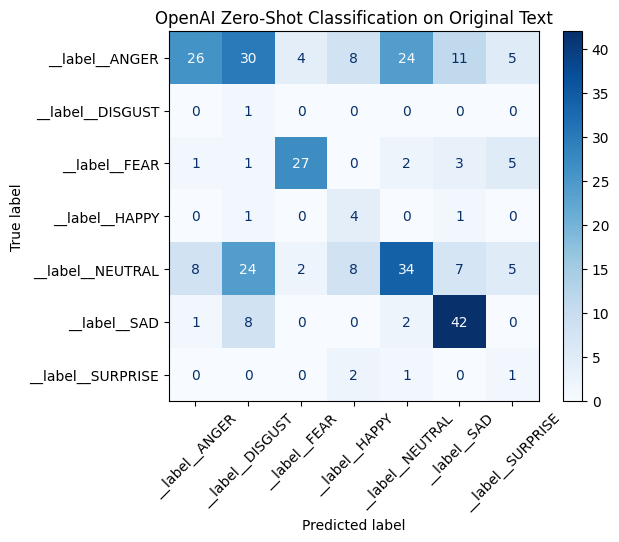


Bootstrap 95% confidence intervals: Original Text
Accuracy CI: mean=0.4510, 95% CI=(0.3913, 0.5084)
Macro F1 CI: mean=0.3816, 95% CI=(0.3323, 0.4331)


In [9]:
# ============================================================
# STEP 4: Evaluate the original, untranslated text
# ============================================================

results_df = translated_df.copy()

results_df["prediction_original"] = results_df["text"].progress_apply(
    lambda x: classify_text(x, class_names)
)

original_metrics = evaluate_predictions(
    results_df,
    prediction_col="prediction_original",
    title="OpenAI Zero-Shot Classification on Original Text"
)

print_bootstrap_intervals(
    results_df,
    prediction_col="prediction_original",
    title="Original Text"
)

  0%|          | 0/300 [00:00<?, ?it/s]


OpenAI Zero-Shot Classification on English-Translated Text
Rows evaluated successfully: 299 / 300
Rows with API/model errors: 1
Accuracy: 0.3880
Macro F1: 0.3086
Weighted F1: 0.4160

Classification report:
                   precision    recall  f1-score   support

   __label__ANGER       0.67      0.15      0.24       108
 __label__DISGUST       0.02      1.00      0.05         1
    __label__FEAR       0.67      0.62      0.64        39
   __label__HAPPY       0.11      0.67      0.19         6
 __label__NEUTRAL       0.49      0.48      0.48        88
     __label__SAD       0.57      0.55      0.56        53
__label__SURPRISE       0.00      0.00      0.00         4

         accuracy                           0.39       299
        macro avg       0.36      0.49      0.31       299
     weighted avg       0.57      0.39      0.42       299



<Figure size 1000x700 with 0 Axes>

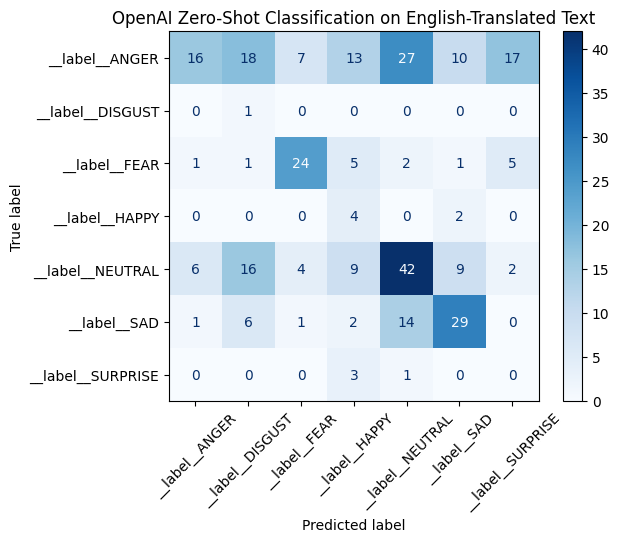


Bootstrap 95% confidence intervals: English-Translated Text
Accuracy CI: mean=0.3866, 95% CI=(0.3311, 0.4448)
Macro F1 CI: mean=0.3072, 95% CI=(0.2647, 0.3514)


In [13]:
# ============================================================
# STEP 5: Evaluate the English-translated text
# ============================================================

# The results_df already contains 'prediction_original' from the previous step.
# We will add 'prediction_english' to the existing DataFrame.
# Removed: results_df = translated_df.copy() to prevent overwriting 'prediction_original'

results_df["prediction_english"] = results_df["text_english"].progress_apply(
    lambda x: classify_text(x, class_names)
)

english_metrics = evaluate_predictions(
    results_df,
    prediction_col="prediction_english",
    title="OpenAI Zero-Shot Classification on English-Translated Text"
)

print_bootstrap_intervals(
    results_df,
    prediction_col="prediction_english",
    title="English-Translated Text"
)

In [14]:
# ============================================================
# STEP 6: Compare original vs English-translated evaluation
# ============================================================

# Ensure results_df is properly initialized with all necessary prediction columns
# Start with a fresh copy of translated_df to ensure a consistent base
# and then add prediction columns if they are missing.
if 'results_df' not in locals() or 'results_df' not in globals() or not isinstance(results_df, pd.DataFrame) or results_df.shape[0] != translated_df.shape[0] or \
   "prediction_original" not in results_df.columns or "prediction_english" not in results_df.columns:
    print("Re-initializing results_df and ensuring prediction columns are present.")
    results_df = translated_df.copy()

    if "prediction_original" not in results_df.columns:
        print("Calculating 'prediction_original' column.")
        results_df["prediction_original"] = results_df["text"].progress_apply(
            lambda x: classify_text(x, class_names)
        )

    if "prediction_english" not in results_df.columns:
        print("Calculating 'prediction_english' column.")
        results_df["prediction_english"] = results_df["text_english"].progress_apply(
            lambda x: classify_text(x, class_names)
        )

# Re-calculate original_metrics and english_metrics if they are not in scope,
# or if prediction columns were just calculated (to ensure fresh metrics).
if 'original_metrics' not in locals() or 'english_metrics' not in locals() or \
   "prediction_original" not in results_df.columns or "prediction_english" not in results_df.columns: # Re-check column presence for robustness
    print("Re-evaluating performance metrics.")
    original_metrics = evaluate_predictions(
        results_df,
        prediction_col="prediction_original",
        title="OpenAI Zero-Shot Classification on Original Text"
    )
    english_metrics = evaluate_predictions(
        results_df,
        prediction_col="prediction_english",
        title="OpenAI Zero-Shot Classification on English-Translated Text"
    )

comparison = pd.DataFrame([
    {"version": "Original text", **original_metrics},
    {"version": "English-translated text", **english_metrics}
])

display(comparison)

# Where did translation change the model's decision?
changed_predictions = results_df[
    (results_df["prediction_original"] != "Error") &
    (results_df["prediction_english"] != "Error") &
    (results_df["prediction_original"] != results_df["prediction_english"])
].copy()

print(f"Number of rows where translation changed the prediction: {len(changed_predictions)}")

display(changed_predictions[
    ["label", "text", "text_english", "prediction_original", "prediction_english"]
].head(20))

# Save final results for later analysis.
results_df.to_csv("original_vs_english_translation_results.csv", index=False)
print("Saved: original_vs_english_translation_results.csv")

Re-initializing results_df and ensuring prediction columns are present.
Calculating 'prediction_original' column.


  0%|          | 0/300 [00:00<?, ?it/s]

Calculating 'prediction_english' column.


  0%|          | 0/300 [00:00<?, ?it/s]

,version,accuracy,macro_f1,weighted_f1,n_success,n_error
0,Original text,0.451505,0.385058,0.495234,299,1
1,English-translated text,0.387960,0.308552,0.415959,299,1


Number of rows where translation changed the prediction: 114


,label,text,text_english,prediction_original,prediction_english
5,__label__SAD,ሙሉውን ሳያነብ አስተያየቱን ሰጠ ብለህ በማሰብህ ራሱ በጣም አዝናለሁ ከላ...,I am very saddened by the thought that he gave...,__label__DISGUST,__label__SAD
7,__label__HAPPY,ሀብታሙ የምተሰርው ሁሉ ፊልም ሁሉ እውናተኝ ነው በነትህ ይመቺህ,Every movie that Habtamu acts in is realistic ...,__label__DISGUST,__label__HAPPY
8,__label__ANGER,ሰለቸን እኮ አረ ኡኡኡኡኡ,"We're tired, oh wow!",__label__ANGER,__label__SURPRISE
10,__label__NEUTRAL,ማንነታቸው በግልጽ ለህዝብ ይፋ መደረግ አለበት።,Their identity must be made public to the people.,__label__NEUTRAL,__label__ANGER
11,__label__ANGER,ኡኡኡኡኡኡኡኡኡኡ አለ አምቡላንስ,"Woo woo woo woo woo woo woo woo woo woo, said ...",__label__SURPRISE,__label__NEUTRAL
12,__label__NEUTRAL,ግን ከእናንተ ወገን ብቻ ነው ውወተ ሜይዴይ,"But it's only from your side, Mayday.",__label__DISGUST,__label__NEUTRAL
18,__label__NEUTRAL,እንዳይገባው የገባው ሰው ይምስለኛል ??,Will the person who entered without permission...,__label__ANGER,__label__FEAR
19,__label__FEAR,ጀዛከላሁም ከይር ኢንሻላህ አሁንም አሰፈሪ እንሆናለን,"Jazakallah khair, inshallah we will still be s...",__label__FEAR,__label__HAPPY
20,__label__ANGER,በጣም ጥሩ ጂምር ነው ተናድጀ ነበር።አሳሪወችም ደንግጠዋል።ንፁሃን ወንድሞ...,"It was a very good gym session, and it was int...",__label__ANGER,__label__HAPPY
25,__label__ANGER,ኡኡኡኡኡ ውድ ነው,"Wow, it's expensive.",__label__NEUTRAL,__label__SURPRISE


Saved: original_vs_english_translation_results.csv


## How to interpret the added evaluation

Use the comparison table to answer whether translating to English improved or weakened performance.

Important things to look for:

1. **Accuracy and macro-F1**
   - Accuracy gives the overall percent correct.
   - Macro-F1 is especially useful when labels are imbalanced because it treats each class more equally.

2. **Bootstrap confidence intervals**
   - If the confidence intervals overlap heavily, the difference may not be meaningful.
   - If the English-translated version has clearly higher macro-F1 with a tighter interval, translation likely helped.

3. **Changed predictions table**
   - This is the most useful qualitative error analysis.
   - Look for cases where translation fixed a wrong original prediction.
   - Also look for cases where translation changed the meaning and made the prediction worse.

This makes the project more rigorous because it does not just report a single performance table; it tests whether an important preprocessing choice, translation to English, changes the model's behavior.